# Red Sea MAGs from leaves and roots comparison

1. Data preparation
2. PCoA leaves vs roots indicating Desulfobacterales and Sedimenticolaceae
3. Metabolic pathways related with S, N and C cycle analysis in Red Sea Roots Desulfobacterales and Sedimenticolaceae
4. Metabolic pathways related with S and N cycle analysis in Red Sea Roots Desulfobacterales and Sedimenticolaceae

In [1]:
#Import libraries
import pandas as pd
from pathlib import Path
import matplotlib.pyplot as plt
import numpy as np

### 1. Data preparation

In [ ]:
# Import files
china_annotations = pd.read_csv(".../tables/china_annotations.tsv", sep="\t")
rs_leaves_annotations = pd.read_csv(".../tables/rs_leaves_annotations.tsv", sep="\t")
rs_roots_annotations = pd.read_csv(".../tables/rs_roots_annotations.tsv", sep="\t")
rsxchina_metadata = pd.read_csv(".../tables/rsxchina_metadata.csv", sep=";")

# Standardize column names
for df in [china_annotations, rs_leaves_annotations, rs_roots_annotations, rsxchina_metadata]:
    df.columns = (
        df.columns
        .str.strip()
        .str.lower()
    )

# Check that genome column exists
for name, df in {
    "annotations_1": china_annotations,
    "annotations_2": rs_leaves_annotations,
    "annotations_3": rs_roots_annotations,
    "metadata": rsxchina_metadata
}.items():

    if "genome" not in df.columns:
        raise ValueError(f"'genome' column not found in {name}")

print("All good")

print(f"Dataset 1: {china_annotations['genome'].nunique()} genomes")
print(f"Dataset 2: {rs_leaves_annotations['genome'].nunique()} genomes")
print(f"Dataset 3: {rs_roots_annotations['genome'].nunique()} genomes")
print(f"Metadata : {rsxchina_metadata['genome'].nunique()} genomes")

All good
Dataset 1: 164 genomes
Dataset 2: 20 genomes
Dataset 3: 153 genomes
Metadata : 337 genomes


In [3]:
#combine annotation files

china_annotations["source"] = "china_annotations"
rs_leaves_annotations["source"] = "rs_leaves_annotations"
rs_roots_annotations["source"] = "rs_roots_annotations"

combined_annotations = pd.concat(
    [china_annotations, rs_leaves_annotations, rs_roots_annotations],
    ignore_index=True
)

In [ ]:
combined_annotations.to_csv(".../tables/combined_annotations.csv", sep=";", index=False)

In [5]:
print("China:", china_annotations["genome"].isna().sum())
print("Leaves:", rs_leaves_annotations["genome"].isna().sum())
print("Roots:", rs_roots_annotations["genome"].isna().sum())

China: 0
Leaves: 0
Roots: 0


In [ ]:
import re

# Initialize dictionary to store KO counts
ko_counts_1 = {}

# Iterate through the DataFrame
for _, row in combined_annotations.iterrows():

    mag = row["genome"]

    # Extract only valid KEGG Orthology identifiers
    pathways = re.findall(r"K\d{5}", str(row["kegg_ko"]))

    # Skip rows with no valid KO annotations
    if len(pathways) == 0:
        continue

    num_pathways = len(pathways)

    if mag not in ko_counts_1:
        ko_counts_1[mag] = {}

    for pathway in pathways:

        if pathway not in ko_counts_1[mag]:
            ko_counts_1[mag][pathway] = 0

        # Distribute the count equally among all KOs annotated to the CDS
        ko_counts_1[mag][pathway] += 1 / num_pathways

In [7]:
kokegg_counts_fixed_1 = pd.DataFrame.from_dict(ko_counts_1, orient='index').fillna(0)

print(kokegg_counts_fixed_1.head())

print(combined_annotations["genome"].isna().sum())

                 K01992  K01990  K01869  K03643    K20276  K07654     K15667  \
GCA_050288185.1    12.0    16.0     2.0     1.0  2.833333     1.0  20.666667   
GCA_050290165.1     5.0     6.0     1.0     0.0  0.500000     0.0   0.000000   
GCA_050304695.1     4.0     4.0     1.0     0.0  0.000000     0.0   0.000000   
GCA_050298695.1     2.0     2.0     2.0     1.0  1.500000     0.0   0.000000   
GCA_050292215.1     3.0     2.5     2.0     0.0  0.000000     0.0   0.000000   

                 K05375  K03281  K00099  ...  K17804  K16219  K17915  K06870  \
GCA_050288185.1     1.0     4.0     3.0  ...     0.0     0.0     0.0     0.0   
GCA_050290165.1     0.0     1.0     0.0  ...     0.0     0.0     0.0     0.0   
GCA_050304695.1     0.0     1.0     1.0  ...     0.0     0.0     0.0     0.0   
GCA_050298695.1     0.0     1.0     1.0  ...     0.0     0.0     0.0     0.0   
GCA_050292215.1     0.0     0.0     1.0  ...     0.0     0.0     0.0     0.0   

                 K08154  K01793  K0309

In [8]:
print("NaNs:", combined_annotations["genome"].isna().sum())

print("Empty strings:",
      (combined_annotations["genome"].astype(str).str.strip() == "").sum())

NaNs: 0
Empty strings: 0


In [9]:
values = kokegg_counts_fixed_1.stack()

print(values.describe())
print(f"Zeros: {(values == 0).mean()*100:.2f}%")
print(f"Non-zero: {(values > 0).mean()*100:.2f}%")

count    3.191727e+06
mean     1.911157e-01
std      6.916583e-01
min      0.000000e+00
25%      0.000000e+00
50%      0.000000e+00
75%      0.000000e+00
max      2.402500e+02
dtype: float64
Zeros: 85.17%
Non-zero: 14.83%


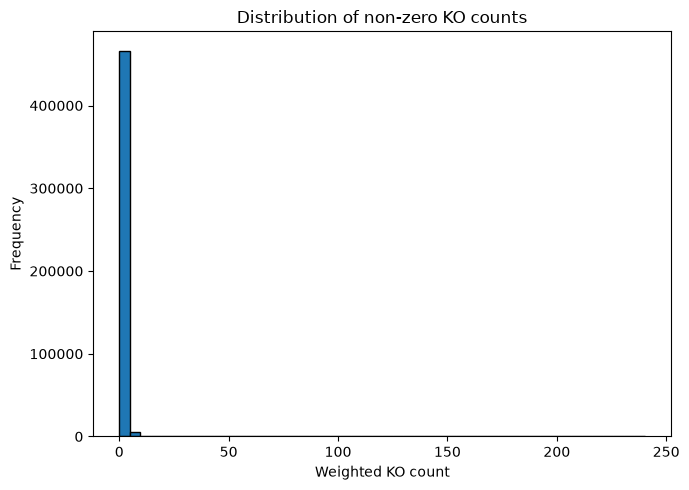

In [10]:
nonzero = values[values > 0]

plt.figure(figsize=(7,5))
plt.hist(nonzero, bins=50, edgecolor="black")
plt.xlabel("Weighted KO count")
plt.ylabel("Frequency")
plt.title("Distribution of non-zero KO counts")
plt.tight_layout()
plt.show()

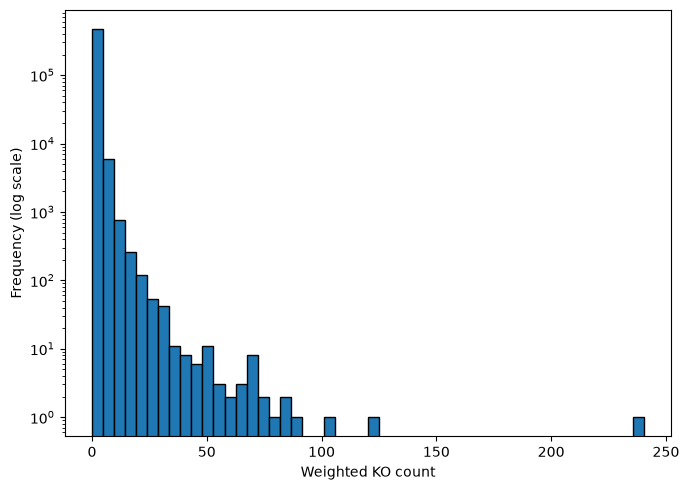

In [11]:
plt.figure(figsize=(7,5))
plt.hist(nonzero, bins=50, edgecolor="black", log=True)
plt.xlabel("Weighted KO count")
plt.ylabel("Frequency (log scale)")
plt.tight_layout()
plt.show()

In [12]:
# Create a mapping of MAG -> completeness
completeness = (
    rsxchina_metadata[["genome", "completeness"]]
    .drop_duplicates()
    .set_index("genome")["completeness"]
)

# Convert from % to fraction
completeness = completeness / 100

# Match the order of the KO matrix
completeness = completeness.reindex(kokegg_counts_fixed_1.index)

# Check for MAGs without completeness information
print(f"Missing completeness values: {completeness.isna().sum()}")

# Correct KO counts
ko_matrix_corrected = kokegg_counts_fixed_1.div(completeness, axis=0)

Missing completeness values: 0


THIS IS A PARENTESIS TO SEARCH FOR SPECIFIC GENES

In [ ]:
# List of KOs to search
ko_codes_tocheck = [
    "K04641",
    "K04642",
    "K04643",
    "K06443",
    "K00514",
    "K14594"
]

# Select leaf genomes
leaf_genomes = rsxchina_metadata.loc[
    rsxchina_metadata["compartment"] == "leaves",
    "genome"
]

# Keep only genomes present in the KO matrix
leaf_matrix = ko_matrix_corrected.loc[
    ko_matrix_corrected.index.intersection(leaf_genomes)
]

# Check which requested KOs exist
present_kos = [ko for ko in ko_codes_tocheck if ko in leaf_matrix.columns]
missing_kos = [ko for ko in ko_codes_tocheck if ko not in leaf_matrix.columns]

print(f"KOs present in matrix ({len(present_kos)}):")
print(present_kos)

print(f"\nKOs NOT found in matrix ({len(missing_kos)}):")
print(missing_kos)

# Extract only the existing KO columns
selected = leaf_matrix[present_kos]

# Keep genomes with at least one KO present
leaf_hits = selected[(selected > 0).any(axis=1)]

print(f"\nNumber of leaf genomes with at least one target KO: {leaf_hits.shape[0]}")

# Summarize which KOs each genome contains
results = []

for genome, row in leaf_hits.iterrows():

    detected = row[row > 0]

    results.append({
        "genome": genome,
        "n_target_KOs": len(detected),
        "KOs_detected": ", ".join(detected.index),
        "counts": ", ".join(map(str, detected.values.round(3)))
    })

results_df = pd.DataFrame(results)

# Display
print(results_df)

# Optional: save
results_df.to_csv(
    "leaf_genomes_target_KOs.csv",
    index=False
)

KOs present in matrix (4):
['K04641', 'K04642', 'K06443', 'K00514']

KOs NOT found in matrix (2):
['K04643', 'K14594']

Number of leaf genomes with at least one target KO: 6
                 genome  n_target_KOs    KOs_detected        counts
0   Leaves_Mang_3_bin.4             2  K04641, K04642  1.017, 1.017
1  Leaves_Mang_11_bin.1             2  K04641, K04642  1.021, 1.021
2  Leaves_Mang_25_bin.6             1          K06443         3.896
3         Leaves_bin.14             1          K06443         0.617
4         Leaves_bin.17             2  K04641, K00514  1.026, 1.026
5         Leaves_bin.21             1          K06443         1.047


### 2. PCoA leaves vs roots indicating Desulfobacterales and Sedimenticolaceae

In [14]:
from scipy.spatial.distance import pdist, squareform

# Select only Red Sea MAGs from the metadata
redsea_genomes = rsxchina_metadata.loc[
    rsxchina_metadata["location"] == "red_sea",
    "genome"
].dropna().unique()

# Keep only genomes that are present in the KO matrix
redsea_genomes = [
    genome for genome in redsea_genomes
    if genome in kokegg_counts_fixed_1.index
]

print(f"Number of Red Sea MAGs found: {len(redsea_genomes)}")

# Subset the KO matrix
redsea_matrix = kokegg_counts_fixed_1.loc[redsea_genomes]
print(redsea_matrix.shape)

Number of Red Sea MAGs found: 173
(173, 9471)


In [ ]:
# Additional libraries
from scipy.spatial.distance import pdist, squareform
from matplotlib.patches import Ellipse
from skbio.stats.distance import DistanceMatrix
from skbio.stats.ordination import pcoa

# Bray-Curtis distance matrix
bray = squareform(
    pdist(redsea_matrix.values, metric="braycurtis")
)

bray_dm = DistanceMatrix(
    bray,
    ids=redsea_matrix.index
)

# PCoA
pcoa_results = pcoa(bray_dm)
coords = pcoa_results.samples.iloc[:, :2].copy()
coords["genome"] = coords.index

# Add compartment information
coords = coords.merge(rsxchina_metadata[["genome", "compartment"]], on="genome", how="left")
coords.rename(columns={"compartment": "compartment"}, inplace=True)

# Check that all genomes were matched
print(coords["compartment"].value_counts(dropna=False))

# Colors and markers
colors = {
    "leaves": "#4DAF4A",
    "roots": "#8C6BB1"
}

markers = {
    "leaves": "o",
    "roots": "^"
}

# Confidence ellipse
def confidence_ellipse(x, y, ax, n_std=2.0, facecolor="none", **kwargs):

    if len(x) < 3:
        return

    cov = np.cov(x, y)

    vals, vecs = np.linalg.eigh(cov)

    order = vals.argsort()[::-1]

    vals = vals[order]
    vecs = vecs[:, order]

    theta = np.degrees(np.arctan2(*vecs[:, 0][::-1]))

    width = 2 * n_std * np.sqrt(vals[0])
    height = 2 * n_std * np.sqrt(vals[1])

    ellipse = Ellipse(
        (np.mean(x), np.mean(y)),
        width,
        height,
        angle=theta,
        facecolor=facecolor,
        **kwargs
    )

    ax.add_patch(ellipse)

# Plot
fig, ax = plt.subplots(figsize=(7,7))
for group in ["leaves", "roots"]:

    subset = coords[
        coords["compartment"] == group
    ]

    ax.scatter(
        subset["PC1"],
        subset["PC2"],
        color=colors[group],
        marker=markers[group],
        edgecolor="black",
        linewidth=0.5,
        s=70,
        label=group,
        zorder=3
    )

    confidence_ellipse(
        subset["PC1"],
        subset["PC2"],
        ax,
        n_std=2,
        facecolor=colors[group],
        edgecolor=None,
        alpha=0.25
    )

ax.set_xlabel(
    f"PC1 ({pcoa_results.proportion_explained.iloc[0]*100:.1f}%)",
    fontsize=12
)

ax.set_ylabel(
    f"PC2 ({pcoa_results.proportion_explained.iloc[1]*100:.1f}%)",
    fontsize=12
)

ax.legend(frameon=False)

plt.tight_layout()
plt.show()

/home/penamf/miniforge3/envs/python_v3.11/lib/python3.11/site-packages/skbio/stats/ordination/_principal_coordinate_analysis.py:222: RuntimeWarning: EIGH: since no value for dimensions is specified, PCoA for all dimensions will be computed, which may result in long computation time if the original distance matrix is large.
  warn(


Compartment
Roots     153
Leaves     20
Name: count, dtype: int64


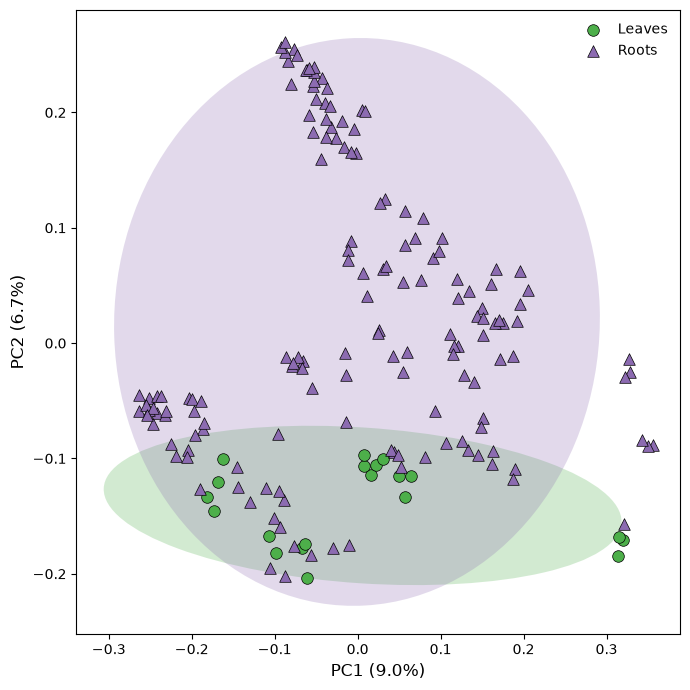

In [ ]:
# Additional libraries
from scipy.spatial.distance import pdist, squareform
from matplotlib.patches import Ellipse
from skbio.stats.distance import DistanceMatrix
from skbio.stats.ordination import pcoa

# Convert KO counts to presence/absence
redsea_binary = (redsea_matrix > 0).astype(int)

# Calculate Jaccard distance matrix
jaccard = squareform(pdist(redsea_binary.values, metric="jaccard"))

jaccard_dm = DistanceMatrix(jaccard, ids=redsea_binary.index)

# Perform PCoA
pcoa_results = pcoa(jaccard_dm)
coords = pcoa_results.samples.iloc[:, :2].copy()
coords["genome"] = coords.index

# Add metadata
coords = coords.merge(rsxchina_metadata[["genome", "compartment"]], on="genome", how="left")

coords.rename(columns={"compartment": "Compartment"}, inplace=True)

coords["Compartment"] = coords["Compartment"].str.capitalize()

print(coords["Compartment"].value_counts())

# Colors
colors = {
    "Leaves": "#4DAF4A",
    "Roots": "#8C6BB1"
}

markers = {
    "Leaves": "o",
    "Roots": "^"
}

# Confidence ellipse
def confidence_ellipse(x, y, ax, n_std=2.0, facecolor="none", **kwargs):

    if len(x) < 3:
        return

    cov = np.cov(x, y)

    vals, vecs = np.linalg.eigh(cov)

    order = vals.argsort()[::-1]

    vals = vals[order]
    vecs = vecs[:, order]

    theta = np.degrees(np.arctan2(*vecs[:, 0][::-1]))

    width = 2 * n_std * np.sqrt(vals[0])
    height = 2 * n_std * np.sqrt(vals[1])

    ellipse = Ellipse(
        (np.mean(x), np.mean(y)),
        width,
        height,
        angle=theta,
        facecolor=facecolor,
        **kwargs
    )

    ax.add_patch(ellipse)

# Plot
fig, ax = plt.subplots(figsize=(7,7))

for group in ["Leaves", "Roots"]:

    subset = coords[
        coords["Compartment"] == group
    ]

    ax.scatter(
        subset["PC1"],
        subset["PC2"],
        color=colors[group],
        marker=markers[group],
        edgecolor="black",
        linewidth=0.5,
        s=70,
        label=group,
        zorder=3
    )

    confidence_ellipse(
        subset["PC1"],
        subset["PC2"],
        ax,
        n_std=2,
        facecolor=colors[group],
        edgecolor=None,
        alpha=0.25
    )

ax.set_xlabel(
    f"PC1 ({pcoa_results.proportion_explained.iloc[0]*100:.1f}%)",
    fontsize=12
)

ax.set_ylabel(
    f"PC2 ({pcoa_results.proportion_explained.iloc[1]*100:.1f}%)",
    fontsize=12
)

ax.legend(frameon=False)

plt.tight_layout()
plt.show()

/home/penamf/miniforge3/envs/python_v3.11/lib/python3.11/site-packages/skbio/stats/ordination/_principal_coordinate_analysis.py:222: RuntimeWarning: EIGH: since no value for dimensions is specified, PCoA for all dimensions will be computed, which may result in long computation time if the original distance matrix is large.
  warn(


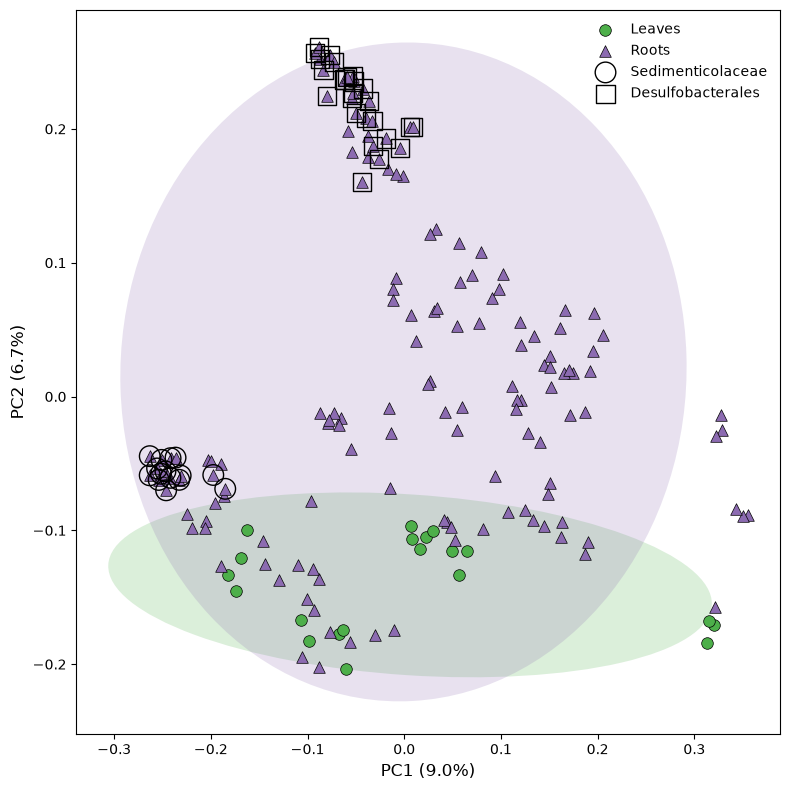

In [ ]:
# Additional libraries
from scipy.spatial.distance import pdist, squareform
from matplotlib.patches import Ellipse
from skbio.stats.distance import DistanceMatrix
from skbio.stats.ordination import pcoa

# Convert KO counts to presence/absence
redsea_binary = (redsea_matrix > 0).astype(int)

# Calculate Jaccard distance matrix
jaccard = squareform(pdist(redsea_binary.values, metric="jaccard"))

jaccard_dm = DistanceMatrix(jaccard, ids=redsea_binary.index)

# PCoA
pcoa_results = pcoa(jaccard_dm)
coords = pcoa_results.samples.iloc[:, :2].copy()
coords["genome"] = coords.index

# Add metadata
coords = coords.merge(rsxchina_metadata[["genome", "compartment", "family", "order"]], on="genome", how="left")

coords.rename(columns={"compartment": "Compartment"}, inplace=True)

coords["Compartment"] = coords["Compartment"].str.capitalize()

# Colors and markers
colors = {
    "Leaves": "#4DAF4A",
    "Roots": "#8C6BB1"
}

markers = {
    "Leaves": "o",
    "Roots": "^"
}

# Confidence ellipse
def confidence_ellipse(x, y, ax, n_std=2.0, facecolor="none", **kwargs):

    if len(x) < 3:
        return

    cov = np.cov(x, y)

    vals, vecs = np.linalg.eigh(cov)

    order = vals.argsort()[::-1]

    vals = vals[order]
    vecs = vecs[:, order]

    theta = np.degrees(np.arctan2(*vecs[:, 0][::-1]))

    width = 2 * n_std * np.sqrt(vals[0])
    height = 2 * n_std * np.sqrt(vals[1])

    ellipse = Ellipse(
        (np.mean(x), np.mean(y)),
        width,
        height,
        angle=theta,
        facecolor=facecolor,
        **kwargs
    )

    ax.add_patch(ellipse)

# Plot
fig, ax = plt.subplots(figsize=(8,8))

for group in ["Leaves", "Roots"]:

    subset = coords[
        coords["Compartment"] == group
    ]

    ax.scatter(
        subset["PC1"],
        subset["PC2"],
        color=colors[group],
        marker=markers[group],
        edgecolor="black",
        linewidth=0.5,
        s=70,
        label=group,
        zorder=2
    )

    confidence_ellipse(
        subset["PC1"],
        subset["PC2"],
        ax,
        n_std=2,
        facecolor=colors[group],
        alpha=0.20
    )

# Highlight Sedimenticolaceae
sed = coords[
    coords["family"].str.contains(
        "Sedimenticolaceae",
        case=False,
        na=False
    )
]

ax.scatter(
    sed["PC1"],
    sed["PC2"],
    s=220,
    facecolors="none",
    edgecolors="black",
    linewidths=1,
    label="Sedimenticolaceae",
    zorder=5
)

# Highlight Desulfobacterales
des = coords[
    coords["order"].str.contains(
        "Desulfobacterales",
        case=False,
        na=False
    )
]

ax.scatter(
    des["PC1"],
    des["PC2"],
    s=170,
    facecolors="none",
    edgecolors="black",
    marker="s",
    linewidths=1,
    label="Desulfobacterales",
    zorder=4
)

# Axis labels
ax.set_xlabel(
    f"PC1 ({pcoa_results.proportion_explained.iloc[0]*100:.1f}%)",
    fontsize=12
)

ax.set_ylabel(
    f"PC2 ({pcoa_results.proportion_explained.iloc[1]*100:.1f}%)",
    fontsize=12
)

ax.legend(frameon=False)

plt.tight_layout()

plt.show()

### 3. Metabolic pathways related with S, N and C cycle analysis in Red Sea Roots Desulfobacterales and Sedimenticolaceae

In [ ]:
# Select genomes of interest

rs_roots_sediment_desulfo_metadata = rsxchina_metadata[
    (rsxchina_metadata["location"] == "red_sea") &
    (rsxchina_metadata["compartment"].str.lower() == "roots") &
    (
        rsxchina_metadata["family"].str.contains(
            "Sedimenticolaceae",
            case=False,
            na=False
        )
        |
        rsxchina_metadata["order"].str.contains(
            "Desulfobacterales",
            case=False,
            na=False
        )
    )
].copy()

# Keep only genomes present in the KO matrix
rs_roots_sediment_desulfo_genomes = rs_roots_sediment_desulfo_metadata["genome"]

rs_roots_sediment_desulfo_genomes = [
    genome for genome in rs_roots_sediment_desulfo_genomes
    if genome in kokegg_counts_fixed_1.index
]

# Create the submatrix
rs_roots_sediment_desulfo_matrix = kokegg_counts_fixed_1.loc[rs_roots_sediment_desulfo_genomes]

print(rs_roots_sediment_desulfo_matrix.shape)
print(rs_roots_sediment_desulfo_matrix.head())

(41, 9471)
                        K01992    K01990  K01869  K03643    K20276  K07654  \
Roots_Mang_34_bin.4   4.666667  3.833333     1.0     0.0  0.533333     0.0   
Roots_Mang_37_bin.9   5.000000  6.000000     1.0     0.0  0.000000     0.0   
Roots_Mang_43_bin.10  5.333333  5.666667     1.0     0.0  1.200000     0.0   
Roots_bin.123         5.000000  4.500000     0.0     0.0  0.000000     0.0   
Roots_bin.128         3.000000  2.000000     1.0     0.0  0.000000     0.0   

                      K15667  K05375  K03281  K00099  ...  K17804  K16219  \
Roots_Mang_34_bin.4      0.0     0.0     2.0     1.0  ...     0.0     0.0   
Roots_Mang_37_bin.9      0.0     0.0     2.0     1.0  ...     0.0     0.0   
Roots_Mang_43_bin.10     0.0     0.0     2.0     1.0  ...     0.0     0.0   
Roots_bin.123            0.0     0.0     3.0     3.0  ...     0.0     0.0   
Roots_bin.128            0.0     0.0     2.0     1.0  ...     0.0     0.0   

                      K17915  K06870  K08154  K01793  K03

In [19]:
#Import the dataframe with specific genes of pathways of interest

genes_SNC = pd.read_csv("/home/penamf/rsmangroves/02_genomes_annotation/eggnog_mapper/funtional_analysis_final/tables/kos_interest_SNC.tsv", sep="\t")
print(genes_SNC.head())

            Category                             Process  \
0  Sulfur metabolism  Sulfur oxidation Sulfide oxidation   
1  Sulfur metabolism  Sulfur oxidation Sulfide oxidation   
2  Sulfur metabolism  Sulfur oxidation Sulfide oxidation   
3  Sulfur metabolism                    Sulfur oxidation   
4  Sulfur metabolism                         Sox pathway   

                                   Pathway  name  gene ko_code  
0           Sulfide:quinone oxidoreductase   sqr   sqr  K17218  
1  Flavocytochrome c sulfide dehydrogenase  fccA  fccA  K17230  
2  Flavocytochrome c sulfide dehydrogenase  fccB  fccB  K17229  
3                       Sulfur dioxygenase   sdo   sdo  K17725  
4                              Sox complex  soxA  soxA  K17222  


In [20]:
#Matrix with only the present ko of interest

# Extract KO codes of interest
ko_list_SNC = genes_SNC["ko_code"].dropna().unique().tolist()

# Find which KOs are present
ko_present_SNC = [ko for ko in ko_list_SNC if ko in rs_roots_sediment_desulfo_matrix.columns]
ko_missing_SNC = sorted(set(ko_list_SNC) - set(rs_roots_sediment_desulfo_matrix.columns))

print(f"Total KOs in pathway table: {len(ko_list_SNC)}")
print(f"KOs found in matrix: {len(ko_present_SNC)}")
print(f"KOs missing from matrix: {len(ko_missing_SNC)}")

if ko_missing_SNC:
    print("\nMissing KOs:")
    for ko in ko_missing_SNC:
        print(ko)

# Subset KO matrix
ko_matrix_subset_SNC = rs_roots_sediment_desulfo_matrix[ko_present_SNC]

heatmap_SNC = ko_matrix_subset_SNC.copy()

print("\nSubset matrix dimensions:")
print(ko_matrix_subset_SNC.shape)

Total KOs in pathway table: 95
KOs found in matrix: 83
KOs missing from matrix: 12

Missing KOs:
K00386
K17725
K22622
K25123
K25124
K27187
K27188
K27189
K27190
K27191
K27196
K27925

Subset matrix dimensions:
(41, 83)


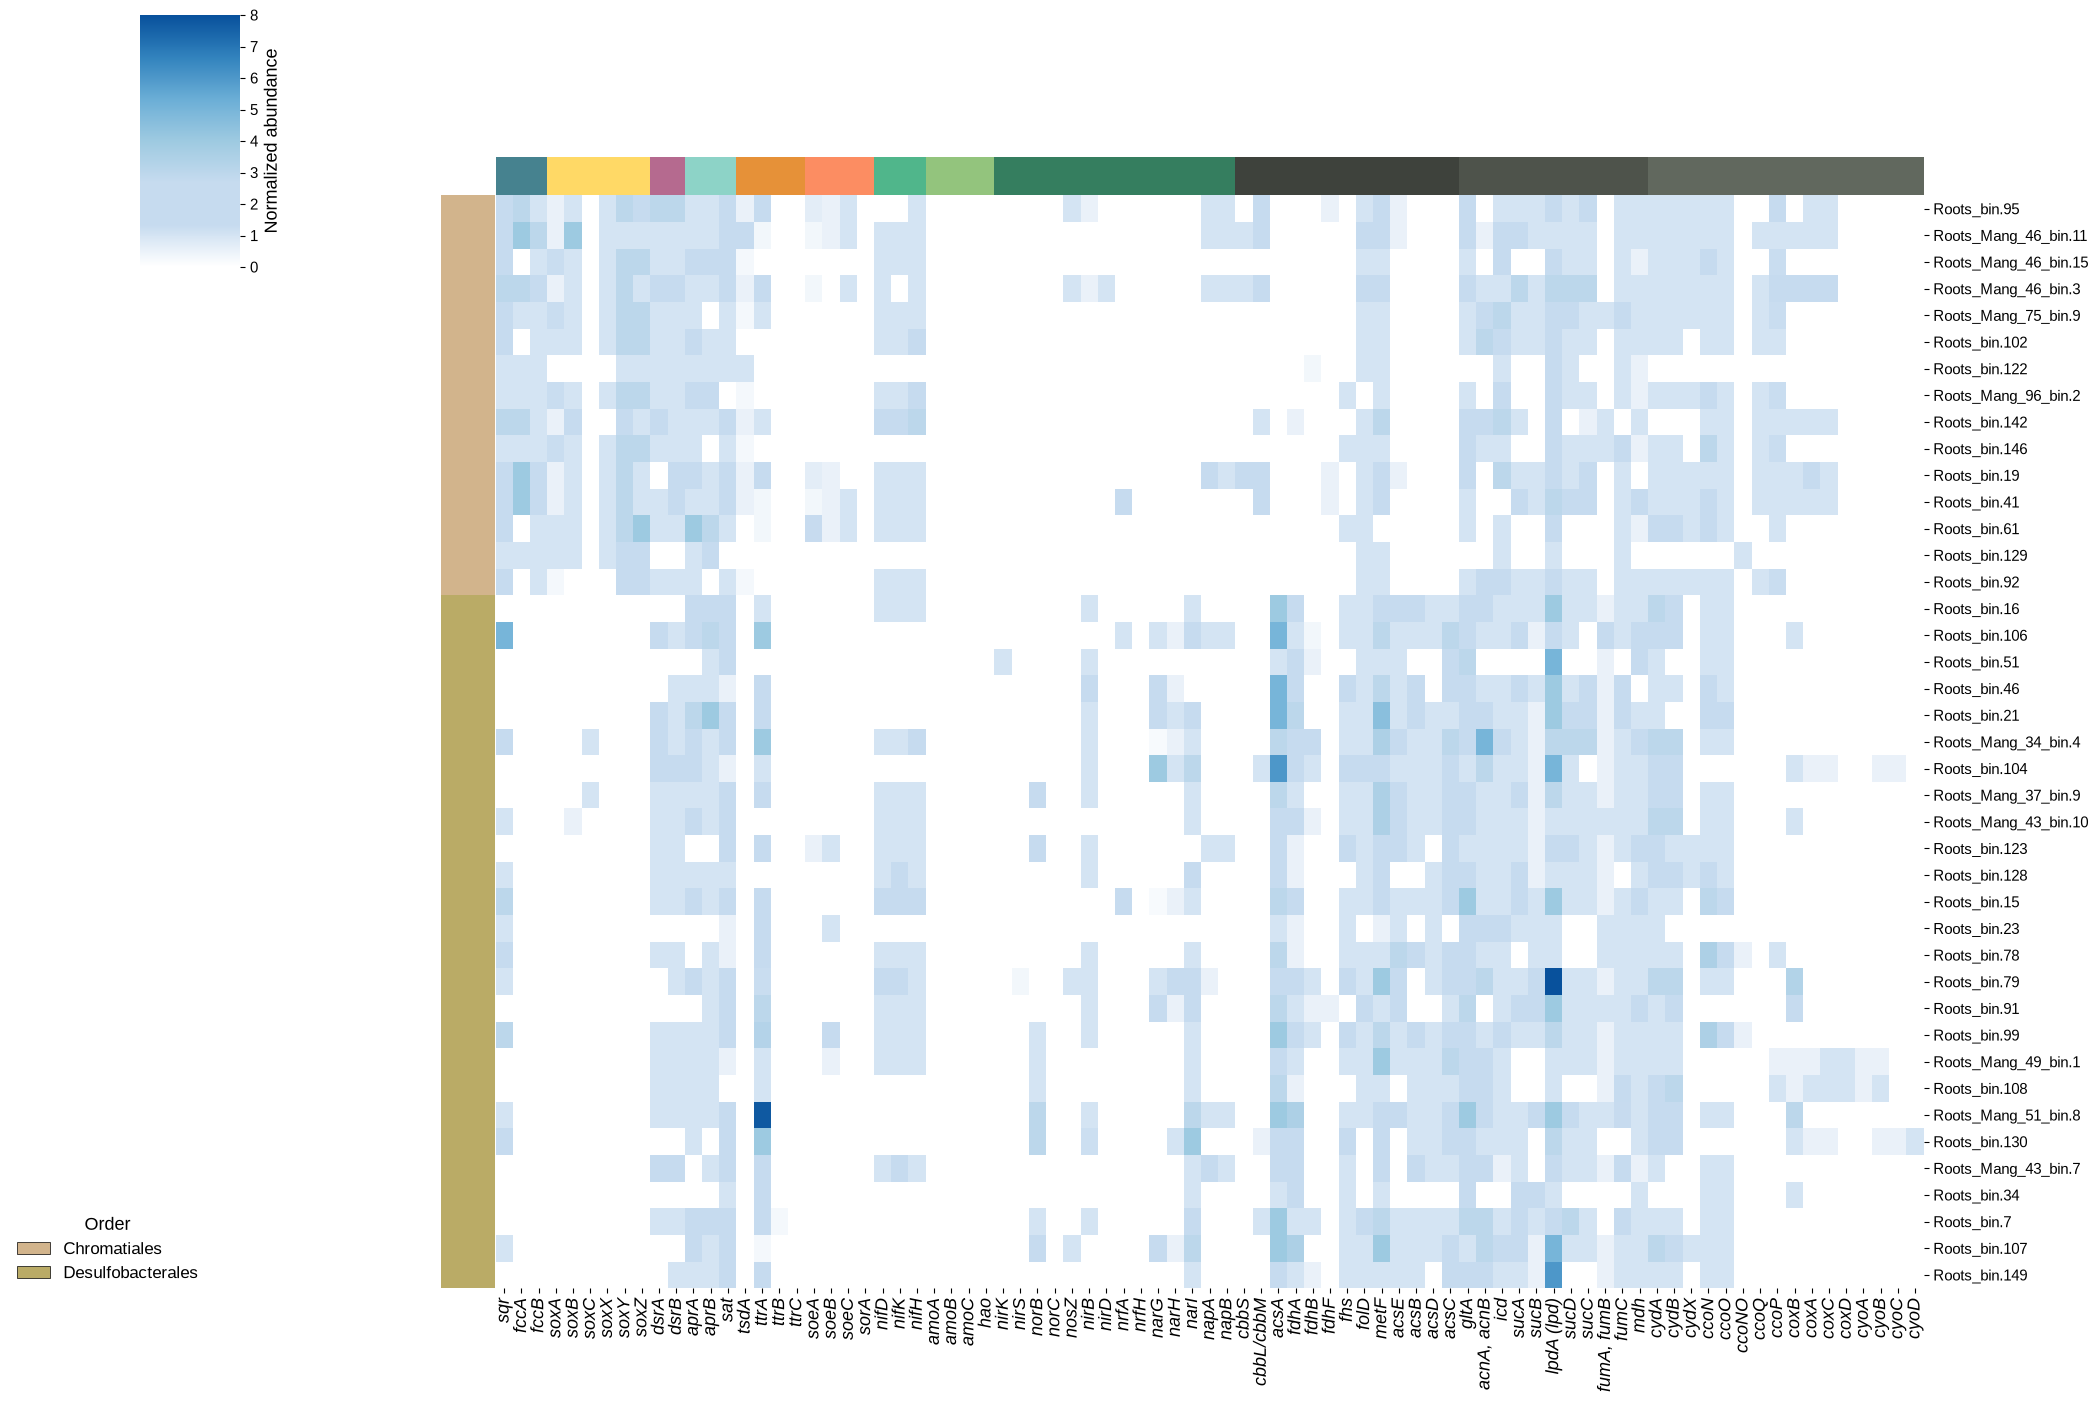

In [ ]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import matplotlib as mpl
from matplotlib.patches import Patch

# style
mpl.rcParams["font.family"] = "Liberation Sans"

cmap = mcolors.LinearSegmentedColormap.from_list(
    "KOmap",
    [
        "#FFFFFF",
        "#C6DBEF",
        "#C6DBEF",
        "#9ECAE1",
        "#6BAED6",
        "#3182BD",
        "#08519C"
    ]
)

# CREATE ROW METADATA
row_metadata = (
    rsxchina_metadata[
        ["genome", "order"]
    ]
    .drop_duplicates()
    .set_index("genome")
)

# keep only genomes present in the matrix
row_metadata = row_metadata.loc[heatmap_SNC.index]

row_metadata = row_metadata.sort_values( # order genomes
    ["order"]
)

heatmap_SNC = heatmap_SNC.loc[row_metadata.index]

origin_palette = { #add colors

    "Chromatiales": "#D2B48C",
    "Desulfobacterales": "#BAAB66"

}

row_colors = row_metadata["order"].map(origin_palette)

# order
process_order = [

    "Sulfur oxidation Sulfide oxidation",
    "Sulfur oxidation",
    "Sox pathway",
    "Sulfur oxidation Reverse DSR/ sulfite reduction",
    "APS oxidation/reduction",
    "Alternative sulfur oxidation (S4I)",
    "Sulfite oxidation",

    "reduction (N fixation)",
    "oxidation (nitrification)",
    "reduction (denitrification)",
    "reduction (DNRA)",
    "reduction (denitrification/DNRA)",

    "C fixation",
    "Central carbon metabolism",
    "Cytochrome oxidases"

]

genes_ordered = genes_SNC.copy()

genes_ordered["Process"] = pd.Categorical(
    genes_ordered["Process"],
    categories=process_order,
    ordered=True
)

# Dictionaries
ko_to_gene = (
    genes_ordered
    .drop_duplicates("ko_code")
    .set_index("ko_code")["gene"]
    .to_dict()
)

ko_to_process = (
    genes_ordered
    .drop_duplicates("ko_code")
    .set_index("ko_code")["Process"]
    .to_dict()
)

# Preserve the order of genes as they appear in genes_SNC
genes_ordered["gene_order"] = range(len(genes_ordered))

ko_order = (
    genes_ordered
    .loc[
        genes_ordered["ko_code"].isin(heatmap_SNC.columns)
    ]
    .sort_values(
        ["Process", "gene_order"]
    )["ko_code"]
    .tolist()
)

heatmap_SNC = heatmap_SNC[ko_order]

# gene labels
gene_labels = {}

for ko in heatmap_SNC.columns:

    gene = ko_to_gene.get(ko, ko)

    gene_labels[ko] = gene

heatmap_plot = heatmap_SNC.rename(
    columns=gene_labels
)

# process colors
process_palette = {

    "Sulfur oxidation Sulfide oxidation": "#46828F",
    "Sulfur oxidation": "#46828F",
    "Sox pathway": "#FFD966",
    "Sulfur oxidation Reverse DSR/ sulfite reduction": "#B56A8F",
    "APS oxidation/reduction": "#8dd3c7",
    "Alternative sulfur oxidation (S4I)": "#e69138",
    "Sulfite oxidation": "#fc8d62",
    "reduction (N fixation)": "#50B68B",
    "reduction (denitrification/DNRA)": "#357E5F",
    "reduction (denitrification)": "#357E5F",
    "reduction (DNRA)": "#357E5F",
    "oxidation (nitrification)": "#93C47D",
    "C fixation": "#3E423C",
    "Central carbon metabolism": "#4E534B",
    "Cytochrome oxidases": "#61685E",

}

# column colors
process_series = (
    pd.Series(
        heatmap_SNC.columns,
        index=heatmap_plot.columns
    )
)

col_colors = (
    process_series
    .map(ko_to_process)
    .map(process_palette)
)

# draw heatmap
g = sns.clustermap(

    heatmap_plot,
    cmap=cmap,
    vmin=0,
    vmax=heatmap_plot.max().max(),
    row_cluster=False,
    col_cluster=False,
    row_colors=row_colors,
    col_colors=col_colors,
    linewidths=0,
    figsize=(20,14),
    xticklabels=True,
    yticklabels=True,
    dendrogram_ratio=(0.18,0.12),
    colors_ratio=(0.03,0.03),
    cbar_kws={
        "label":"Normalized abundance"
    }

)

# remove labels from color strips
g.ax_row_colors.set_xticks([])
g.ax_row_colors.set_yticks([])

g.ax_col_colors.set_xticks([])
g.ax_col_colors.set_yticks([])

# format axes
plt.setp(
    g.ax_heatmap.get_xticklabels(),
    rotation=90,
    fontsize=13,
    fontstyle="italic",
    fontweight="normal",
    color="black",
    fontfamily="Liberation Sans"
)

plt.setp(
    g.ax_heatmap.get_yticklabels(),
    fontsize=11,
    fontfamily="Liberation Sans"
)

g.ax_heatmap.set_xlabel("")
g.ax_heatmap.set_ylabel("")

# remove spines
for spine in g.ax_heatmap.spines.values():
    spine.set_visible(False)

#order legend
order_handles = [

    Patch(
        facecolor=color,
        edgecolor="black",
        linewidth=0.5,
        label=name
    )

    for name, color in origin_palette.items()

]

order_legend = g.ax_heatmap.legend(

    handles=order_handles,
    title="Order",
    loc="lower left",
    bbox_to_anchor=(-0.34,0),
    frameon=False,
    borderaxespad=0,
    prop={
        "family":"Liberation Sans",
        "size":12
    }

)

order_legend.get_title().set_fontfamily("Liberation Sans")
order_legend.get_title().set_fontsize(13)

# process legend
process_handles = [

    Patch(
        facecolor=color,
        edgecolor="black",
        linewidth=0.4,
        label=name
    )

    for name, color in process_palette.items()

]

process_legend = g.ax_col_dendrogram.legend(

    handles=process_handles,
    title="Process",
    loc="upper center",
    bbox_to_anchor=(0.5,1.45),
    ncol=3,
    frameon=False,
    prop={
        "family":"Liberation Sans",
        "size":12
    }

)

process_legend.get_title().set_fontfamily("Liberation Sans")
process_legend.get_title().set_fontsize(13)

# colorbar
g.cax.set_ylabel(

    "Normalized abundance",
    fontsize=13,
    fontfamily="Liberation Sans"

)

g.cax.tick_params(
    labelsize=11
)

g.ax_row_dendrogram.set_visible(False)
g.ax_col_dendrogram.set_visible(False)

plt.show()

### 4. Metabolic pathways related with S and N cycle analysis in Red Sea Roots Desulfobacterales and Sedimenticolaceae

In [22]:
# Keep only sulfur and nitrogen metabolism

genes_SN = genes_SNC[
    genes_SNC["Category"].isin([
        "Sulfur metabolism",
        "Nitrogen metabolism"
    ])
].copy()

In [23]:
#Matrix with only the present ko of interest

# Extract KO codes

ko_list_SN = genes_SN["ko_code"].dropna().unique().tolist()

ko_present_SN = [
    ko for ko in ko_list_SN
    if ko in rs_roots_sediment_desulfo_matrix.columns
]

ko_matrix_subset_SN = rs_roots_sediment_desulfo_matrix[
    ko_present_SN
].copy()

heatmap_SN = ko_matrix_subset_SN.copy()

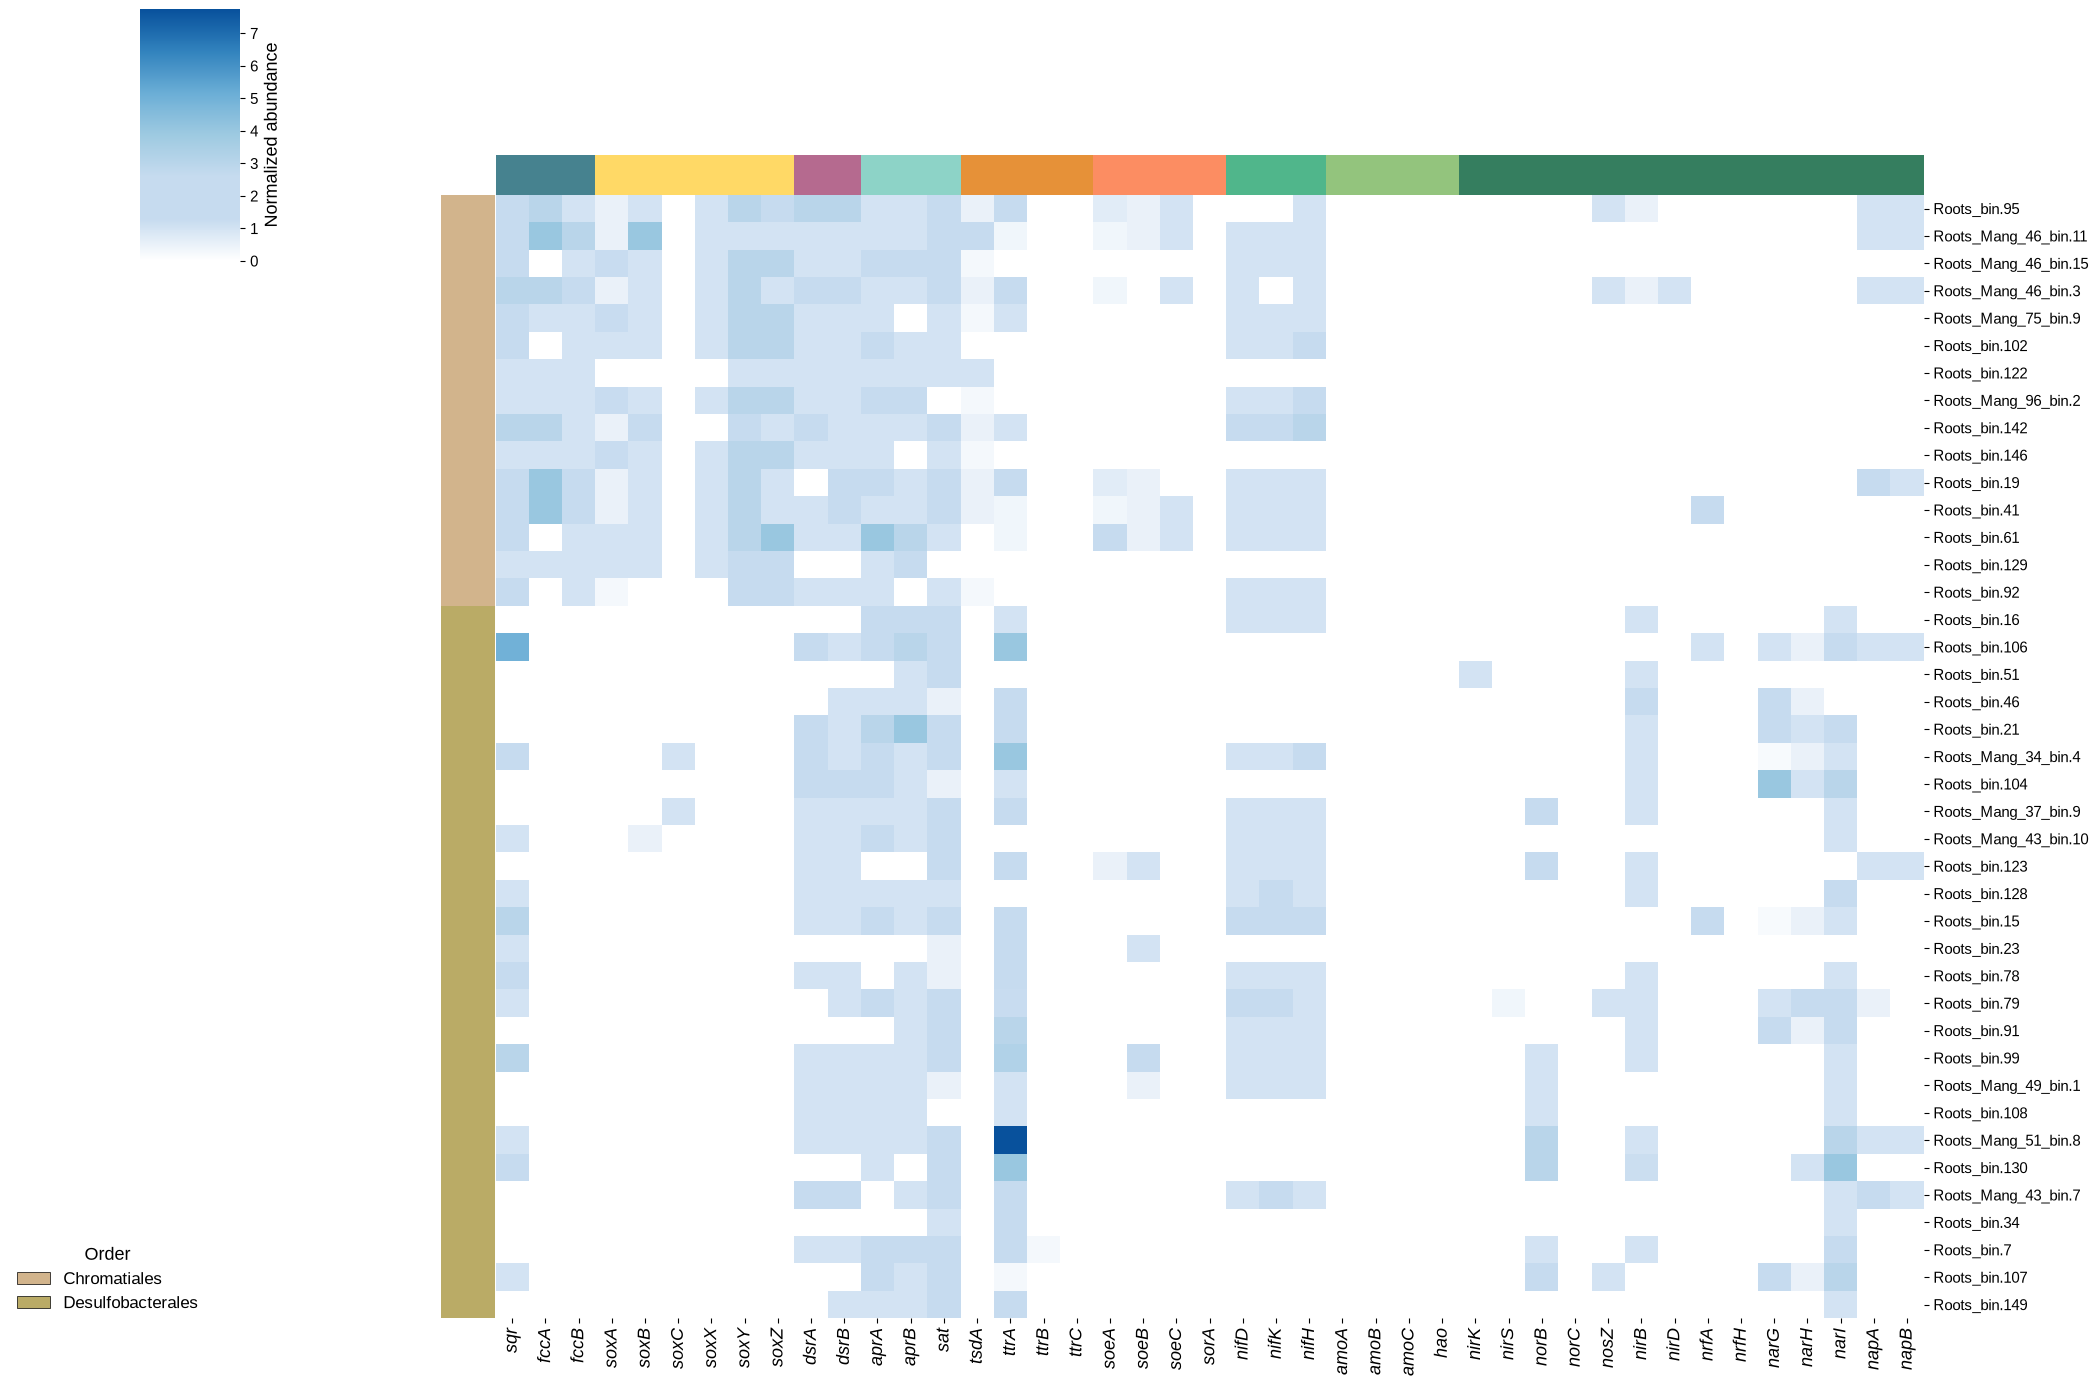

In [ ]:
#Additional libraries
import matplotlib.colors as mcolors
import matplotlib as mpl
from matplotlib.patches import Patch

# style
mpl.rcParams["font.family"] = "Liberation Sans"

cmap = mcolors.LinearSegmentedColormap.from_list(
    "KOmap",
    [
        "#FFFFFF",
        "#C6DBEF",
        "#C6DBEF",
        "#9ECAE1",
        "#6BAED6",
        "#3182BD",
        "#08519C"
    ]
)

# CREATE ROW METADATA
row_metadata = (
    rsxchina_metadata[
        ["genome", "order"]
    ]
    .drop_duplicates()
    .set_index("genome")
)

# keep only genomes present in the matrix
row_metadata = row_metadata.loc[heatmap_SN.index]

row_metadata = row_metadata.sort_values( # order genomes
    ["order"]
)

heatmap_SN = heatmap_SN.loc[row_metadata.index]

origin_palette = { #add colors

    "Chromatiales": "#D2B48C",
    "Desulfobacterales": "#BAAB66"

}

row_colors = row_metadata["order"].map(origin_palette)

# order

process_order = [

    "Sulfur oxidation Sulfide oxidation",
    "Sulfur oxidation",
    "Sox pathway",
    "Sulfur oxidation Reverse DSR/ sulfite reduction",
    "APS oxidation/reduction",
    "Alternative sulfur oxidation (S4I)",
    "Sulfite oxidation",

    "reduction (N fixation)",
    "oxidation (nitrification)",
    "reduction (denitrification)",
    "reduction (DNRA)",
    "reduction (denitrification/DNRA)",

]

genes_ordered = genes_SN.copy()

genes_ordered["Process"] = pd.Categorical(
    genes_ordered["Process"],
    categories=process_order,
    ordered=True
)

# Dictionaries

ko_to_gene = (
    genes_ordered
    .drop_duplicates("ko_code")
    .set_index("ko_code")["gene"]
    .to_dict()
)

ko_to_process = (
    genes_ordered
    .drop_duplicates("ko_code")
    .set_index("ko_code")["Process"]
    .to_dict()
)

# Preserve the order of genes as they appear in genes_SNC
genes_ordered["gene_order"] = range(len(genes_ordered))

ko_order = (
    genes_ordered
    .loc[
        genes_ordered["ko_code"].isin(heatmap_SN.columns)
    ]
    .sort_values(
        ["Process", "gene_order"]
    )["ko_code"]
    .tolist()
)

heatmap_SN = heatmap_SN[ko_order]

# gene labels
gene_labels = {}

for ko in heatmap_SN.columns:

    gene = ko_to_gene.get(ko, ko)

    gene_labels[ko] = gene

heatmap_plot = heatmap_SN.rename(
    columns=gene_labels
)

# process colors
process_palette = {

    "Sulfur oxidation Sulfide oxidation": "#46828F",
    "Sulfur oxidation": "#46828F",
    "Sox pathway": "#FFD966",
    "Sulfur oxidation Reverse DSR/ sulfite reduction": "#B56A8F",
    "APS oxidation/reduction": "#8dd3c7",
    "Alternative sulfur oxidation (S4I)": "#e69138",
    "Sulfite oxidation": "#fc8d62",
    "reduction (N fixation)": "#50B68B",
    "reduction (denitrification/DNRA)": "#357E5F",
    "reduction (denitrification)": "#357E5F",
    "reduction (DNRA)": "#357E5F",
    "oxidation (nitrification)": "#93C47D"

}

# column colors
process_series = (
    pd.Series(
        heatmap_SN.columns,
        index=heatmap_plot.columns
    )
)

col_colors = (
    process_series
    .map(ko_to_process)
    .map(process_palette)
)

# draw heatmap
g = sns.clustermap(

    heatmap_plot,
    cmap=cmap,
    vmin=0,
    vmax=heatmap_plot.max().max(),
    row_cluster=False,
    col_cluster=False,
    row_colors=row_colors,
    col_colors=col_colors,
    linewidths=0,
    figsize=(20,14),
    xticklabels=True,
    yticklabels=True,
    dendrogram_ratio=(0.18,0.12),
    colors_ratio=(0.03,0.03),
    cbar_kws={
        "label":"Normalized abundance"
    }

)

# remove labels from color strips
g.ax_row_colors.set_xticks([])
g.ax_row_colors.set_yticks([])

g.ax_col_colors.set_xticks([])
g.ax_col_colors.set_yticks([])

# format axes
plt.setp(
    g.ax_heatmap.get_xticklabels(),
    rotation=90,
    fontsize=13,
    fontstyle="italic",
    fontweight="normal",
    color="black",
    fontfamily="Liberation Sans"
)

plt.setp(
    g.ax_heatmap.get_yticklabels(),
    fontsize=11,
    fontfamily="Liberation Sans"
)

g.ax_heatmap.set_xlabel("")
g.ax_heatmap.set_ylabel("")

# remove spines
for spine in g.ax_heatmap.spines.values():
    spine.set_visible(False)

#order legend

order_handles = [

    Patch(
        facecolor=color,
        edgecolor="black",
        linewidth=0.5,
        label=name
    )

    for name, color in origin_palette.items()

]

order_legend = g.ax_heatmap.legend(

    handles=order_handles,
    title="Order",
    loc="lower left",
    bbox_to_anchor=(-0.34,0),
    frameon=False,
    borderaxespad=0,
    prop={
        "family":"Liberation Sans",
        "size":12
    }

)

order_legend.get_title().set_fontfamily("Liberation Sans")
order_legend.get_title().set_fontsize(13)

# process legend

process_handles = [

    Patch(
        facecolor=color,
        edgecolor="black",
        linewidth=0.4,
        label=name
    )

    for name, color in process_palette.items()

]

process_legend = g.ax_col_dendrogram.legend(

    handles=process_handles,
    title="Process",
    loc="upper center",
    bbox_to_anchor=(0.5,1.45),
    ncol=3,
    frameon=False,
    prop={
        "family":"Liberation Sans",
        "size":12
    }

)

process_legend.get_title().set_fontfamily("Liberation Sans")
process_legend.get_title().set_fontsize(13)

# colorbar

g.cax.set_ylabel(

    "Normalized abundance",
    fontsize=13,
    fontfamily="Liberation Sans"

)

g.cax.tick_params(
    labelsize=11
)


g.ax_row_dendrogram.set_visible(False)
g.ax_col_dendrogram.set_visible(False)


plt.show()